<div style="border-bottom: 4px solid #003366; margin-bottom: 20px; padding-bottom: 10px; display: flex; justify-content: space-between; align-items: center;">
    <div style="flex-grow: 1;">
        <h1 style="color: #003366; font-family: 'Helvetica', sans-serif; margin-bottom: 5px;">MAT1610: Cálculo I</h1>
        <h2 style="color: #555; margin-top: 0; margin-bottom: 10px;">Laboratorio 04: La Derivada</h2>
        <p style="margin: 2px 0;"><b>Profesores:</b> Equipo Docente | <b>Fecha:</b> Septiembre, 2026</p>
        <p style="margin: 2px 0;"><b>Institución:</b> Facultad de Matemáticas, Pontificia Universidad Católica de Chile</p>
    </div>
    <div style="flex: 0 0 auto; margin-left: 20px;">
        <img src="../source/FacMatematicas-15.png" alt="Logo UC" style="height: 60px; width: auto;">
    </div>
</div>

<div style="border: 1px solid #2980b9; border-left: 8px solid #2980b9; padding: 15px; border-radius: 5px; margin-bottom: 20px;">
    <h3 style="color: #2980b9; margin-top: 0;">Contexto y Referencias</h3>
    <p>Basado en los <b>Capítulos 2 y 3</b> del libro <i>Cálculo de una variable: Trascendentes Tempranas (James Stewart)</i>. La derivada es la herramienta analítica definitiva para estudiar el cambio. En la ingeniería moderna, nos permite analizar la dinámica de los sistemas (velocidades y aceleraciones de mecanismos), encontrar el diseño que minimiza costos o maximiza la resistencia estructural (optimización), y establecer garantías teóricas sobre el comportamiento físico. En este laboratorio usaremos Python para manipular derivadas algebraica y visualmente.</p>
</div>

<div style="display: flex; gap: 20px;">
    <div style="flex: 1; border: 1px solid #27ae60; border-left: 8px solid #27ae60; padding: 15px; border-radius: 5px;">
        <h3 style="color: #27ae60; margin-top: 0;">Contenidos</h3>
        <ol>
            <li>Derivadas, notación y propiedades (Cálculo Simbólico).</li>
            <li>Grafos de derivadas (Conexión cinemática).</li>
            <li>Valores extremos (Puntos críticos y Optimización).</li>
            <li>El Teorema del Valor Medio (TVM).</li>
        </ol>
    </div>
    <div style="flex: 1; border: 1px solid #f39c12; border-left: 8px solid #f39c12; padding: 15px; border-radius: 5px;">
        <h3 style="color: #f39c12; margin-top: 0;">Objetivos de Aprendizaje</h3>
        <ul>
            <li>Automatizar el cálculo de derivadas y derivadas de orden superior utilizando las reglas de <code>SymPy</code>.</li>
            <li>Interpretar visualmente cómo los ceros de la derivada corresponden a los picos y valles de una función.</li>
            <li>Encontrar máximos y mínimos locales calculando y clasificando puntos críticos.</li>
            <li>Demostrar gráfica y analíticamente el Teorema del Valor Medio en problemas físicos.</li>
        </ul>
    </div>
</div>


In [1]:
# Importar librerías de la sesión
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Configuración para visualización matemática
sp.init_printing()
%matplotlib inline

# Configuración de estilo
try: plt.style.use('seaborn-v0_8-whitegrid')
except: plt.style.use('seaborn-whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)


# **1. Derivadas, Notación y Propiedades**

La derivada de una función $f(x)$, denotada como $f'(x)$ (Lagrange) o $\frac{df}{dx}$ (Leibniz), es el límite de la razón de cambio promedio. Su definición formal es:
$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

Computacionalmente, `SymPy` implementa todas las reglas de derivación demostradas (potencia, producto, cociente, regla de la cadena) a través del comando `sp.diff()`, entregando resultados analíticos exactos.


### Ejemplo 1.1: Cálculo Analítico y Derivadas de Orden Superior
Calculemos la primera y segunda derivada de la función de un oscilador amortiguado: $y(t) = e^{-0.5t} \cos(3t)$. Esta es una aplicación directa de la regla del producto y de la cadena.


In [2]:
# Ejemplo 1.1: Derivadas de orden superior con SymPy
t = sp.Symbol('t')
y = sp.exp(-0.5*t) * sp.cos(3*t)

# Primera derivada (Velocidad si y es posición)
dy_dt = sp.diff(y, t)

# Segunda derivada (Aceleración) - Se indica el orden '2' al final
d2y_dt2 = sp.diff(y, t, 2)

print("Función original y(t):")
display(y)
print("\nPrimera Derivada y'(t):")
display(dy_dt)
print("\nSegunda Derivada y''(t):")
display(d2y_dt2)


Función original y(t):



Primera Derivada y'(t):



Segunda Derivada y''(t):


### Ejemplo 1.2: Evaluando la Derivada en un Punto Especifico
La derivada evaluada en un punto $x=a$ representa la pendiente de la recta tangente ($m = f'(a)$). Evaluemos la derivada de la función $f(x) = \ln(x^2 + 1)$ en el punto $x=2$.


Derivada general f'(x):


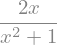


Al evaluar en x=2, la pendiente de la recta tangente es: 4/5


In [3]:
# Ejemplo 1.2: Evaluación de la derivada
x = sp.Symbol('x')
f = sp.ln(x**2 + 1)

# 1. Calculamos la derivada simbólica general
df = sp.diff(f, x)

# 2. Evaluamos f'(2) usando .subs()
pendiente_en_2 = df.subs(x, 2)

print("Derivada general f'(x):")
display(df)
print(f"\nAl evaluar en x=2, la pendiente de la recta tangente es: {pendiente_en_2}")


### Ejemplo 1.3: Automatización de la Regla del Cociente y Simplificación
Para funciones racionales complejas, derivar a mano es propenso a errores. Veremos cómo `SymPy` deriva $g(x) = \frac{\sin(2x)}{x^2 + 1}$ y cómo agrupar algebraicamente el resultado con `sp.simplify()`.


Derivada sin simplificar (Aplicación directa de reglas):


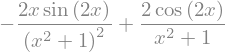


Derivada factorizada y simplificada:


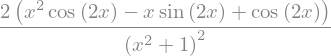

In [4]:
# Ejemplo 1.3: Regla del cociente y factor común
g = sp.sin(2*x) / (x**2 + 1)

# Derivación cruda
dg = sp.diff(g, x)
print("Derivada sin simplificar (Aplicación directa de reglas):")
display(dg)

# Usamos factor y simplify para compactar la respuesta a su forma más elegante
dg_simplificada = sp.factor(sp.simplify(dg))
print("\nDerivada factorizada y simplificada:")
display(dg_simplificada)


# **2. Grafos de Derivadas**

La gráfica de la derivada $f'(x)$ es una "radiografía" fundamental de la función original $f(x)$:
* Cuando $f'(x) > 0$ (gráfica sobre el eje $x$), la gráfica de $f(x)$ **sube** (es creciente).
* Cuando $f'(x) < 0$ (gráfica bajo el eje $x$), la gráfica de $f(x)$ **baja** (es decreciente).
* Cuando $f'(x) = 0$ (cortes en el eje $x$), la curva original tiene una **tangente horizontal**.


### Ejemplo 2.1: Análisis Gráfico Apilado (Cinemática)
Analizaremos la posición de una partícula $s(t) = t^3 - 6t^2 + 9t$. Graficaremos la posición y la velocidad ($v(t) = s'(t)$) en paneles apilados para visualizar cómo los ceros de la velocidad coinciden con los retornos de posición.


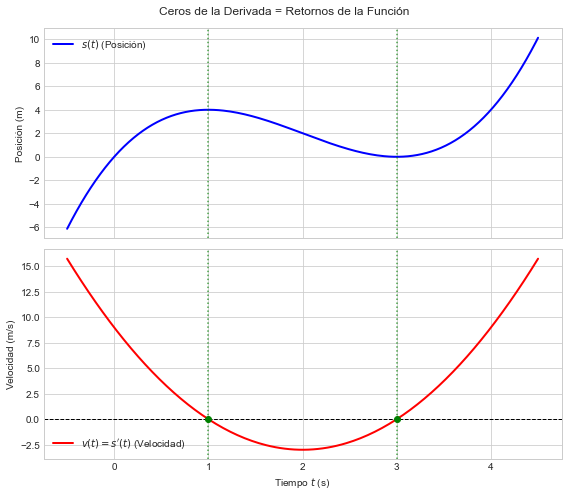

In [5]:
# Ejemplo 2.1: Posición vs Velocidad
t = sp.Symbol('t')
s_expr = t**3 - 6*t**2 + 9*t
v_expr = sp.diff(s_expr, t)

# Convertir a funciones evaluables numéricamente
s_num = sp.lambdify(t, s_expr, 'numpy')
v_num = sp.lambdify(t, v_expr, 'numpy')

t_vals = np.linspace(-0.5, 4.5, 200)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 7))

# Gráfico Posición
ax1.plot(t_vals, s_num(t_vals), color='blue', lw=2, label='$s(t)$ (Posición)')
ax1.set_ylabel('Posición (m)')
ax1.legend()

# Gráfico Velocidad
ax2.plot(t_vals, v_num(t_vals), color='red', lw=2, label='$v(t) = s\'(t)$ (Velocidad)')
ax2.axhline(0, color='black', lw=1, linestyle='--')
ax2.set_ylabel('Velocidad (m/s)')
ax2.set_xlabel('Tiempo $t$ (s)')
ax2.legend()

# Marcar ceros de la derivada
raices_v = sp.solve(v_expr, t)
for raiz in raices_v:
    r_val = float(raiz)
    ax1.axvline(r_val, color='green', linestyle=':', alpha=0.7)
    ax2.axvline(r_val, color='green', linestyle=':', alpha=0.7)
    ax2.scatter([r_val], [0], color='green', zorder=5)

plt.suptitle('Ceros de la Derivada = Retornos de la Función')
plt.tight_layout()
plt.show()


### Ejemplo 2.2: Familia de Derivadas (Desfasaje)
Superpondremos las tres funciones $f(x) = \sin(x)$, $f'(x) = \cos(x)$ y $f''(x) = -\sin(x)$ en un mismo plano. En ingeniería eléctrica o vibraciones mecánicas, esto muestra el desfase de $\pi/2$ entre posición, velocidad y aceleración armónica.


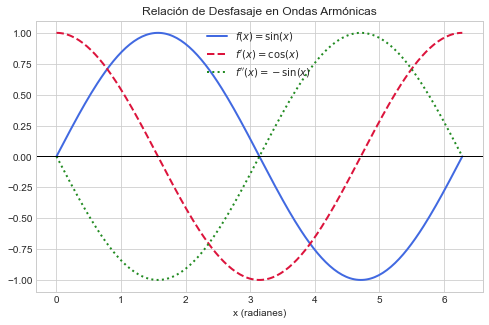

In [6]:
# Ejemplo 2.2: f, f', f'' superpuestas
x_vals = np.linspace(0, 2*np.pi, 200)
f_vals = np.sin(x_vals)
df_vals = np.cos(x_vals)    # Primera derivada
d2f_vals = -np.sin(x_vals)  # Segunda derivada

plt.plot(x_vals, f_vals, label='$f(x) = \sin(x)$', lw=2, color='royalblue')
plt.plot(x_vals, df_vals, label='$f\'(x) = \cos(x)$', lw=2, linestyle='--', color='crimson')
plt.plot(x_vals, d2f_vals, label='$f\'\'(x) = -\sin(x)$', lw=2, linestyle=':', color='forestgreen')

plt.axhline(0, color='black', lw=1)
plt.title("Relación de Desfasaje en Ondas Armónicas")
plt.xlabel("x (radianes)")
plt.legend()
plt.show()


### Ejemplo 2.3: Construcción de la Recta Tangente Dinámica
Para ver a la derivada en acción como "pendiente", construiremos la ecuación de la recta tangente ($y = m(x-a) + f(a)$) a la curva $f(x) = \frac{1}{x}$ en el punto $a=0.5$.


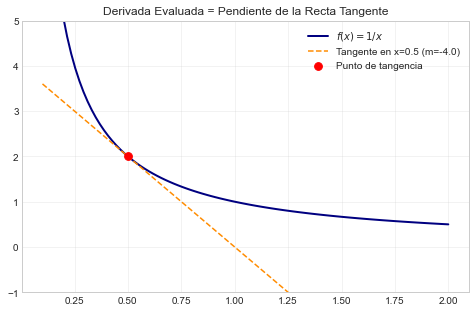

In [7]:
# Ejemplo 2.3: La recta tangente
x = sp.Symbol('x')
f = 1/x
a = 0.5

# Cálculo de la pendiente m = f'(a)
df = sp.diff(f, x)
f_a = float(f.subs(x, a))
m = float(df.subs(x, a))

# Espacio numérico
x_vals = np.linspace(0.1, 2, 100)
f_num = 1 / x_vals
recta_tangente = m * (x_vals - a) + f_a

plt.plot(x_vals, f_num, label='$f(x) = 1/x$', color='navy', lw=2)
plt.plot(x_vals, recta_tangente, label=f'Tangente en x={a} (m={m})', color='darkorange', linestyle='--')
plt.scatter([a], [f_a], color='red', s=60, zorder=5, label='Punto de tangencia')

plt.ylim(-1, 5)
plt.title('Derivada Evaluada = Pendiente de la Recta Tangente')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# **3. Valores Extremos y Optimización**

El **Teorema de Fermat** dicta que si una función continua tiene un máximo o mínimo local en $c$, y su derivada existe allí, obligatoriamente $f'(c) = 0$. Estos puntos se denominan **puntos críticos**.

La optimización de recursos (minimizar la resistencia de un cable, maximizar el volumen de un silo) consiste siempre en tres pasos: modelar la función, hallar sus puntos críticos y clasificarlos.


### Ejemplo 3.1: Búsqueda Algebraica de Puntos Críticos
Buscaremos todos los puntos críticos del polinomio de cuarto grado $f(x) = 3x^4 - 16x^3 + 18x^2$ resolviendo rigurosamente la ecuación $f'(x) = 0$ con `SymPy`.


In [8]:
# Ejemplo 3.1: Puntos Críticos
x = sp.Symbol('x')
f = 3*x**4 - 16*x**3 + 18*x**2

# 1. Derivamos
df = sp.diff(f, x)

# 2. Igualamos a cero y resolvemos
puntos_criticos = sp.solve(df, x)

print("Derivada f'(x):")
display(df)
print(f"\nPuntos críticos encontrados al resolver f'(x) = 0: x = {puntos_criticos}")


Derivada f'(x):



Puntos críticos encontrados al resolver f'(x) = 0: x = [0, 1, 3]


### Ejemplo 3.2: Clasificando Extremos con la Segunda Derivada
Usaremos la **Prueba de la Segunda Derivada** sobre los puntos críticos descubiertos.
* Si $f''(c) > 0 \implies$ Curva cóncava hacia arriba $\implies$ **Mínimo local**.
* Si $f''(c) < 0 \implies$ Curva cóncava hacia abajo $\implies$ **Máximo local**.


In [9]:
# Ejemplo 3.2: Prueba de la Segunda Derivada
d2f = sp.diff(df, x)
print("Segunda Derivada f''(x):", d2f, "\n")

# Análisis iterativo
for pc in puntos_criticos:
    eval_segunda = d2f.subs(x, pc)
    valor_f = f.subs(x, pc)
    
    if eval_segunda > 0:
        tipo = "Mínimo local"
    elif eval_segunda < 0:
        tipo = "Máximo local"
    else:
        tipo = "Prueba no concluyente (Posible punto de Inflexión)"
        
    print(f"En el punto crítico x = {pc}:")
    print(f"  El valor f''({pc}) es {eval_segunda} --> ¡Es un {tipo}!")
    print(f"  El valor extremo de la función es y = {valor_f}\n")


Segunda Derivada f''(x): 36*x**2 - 96*x + 36 

En el punto crítico x = 0:
  El valor f''(0) es 36 --> ¡Es un Mínimo local!
  El valor extremo de la función es y = 0

En el punto crítico x = 1:
  El valor f''(1) es -24 --> ¡Es un Máximo local!
  El valor extremo de la función es y = 5

En el punto crítico x = 3:
  El valor f''(3) es 72 --> ¡Es un Mínimo local!
  El valor extremo de la función es y = -27



### Ejemplo 3.3: Aplicación - Maximización de Volumen (Caja de Cartón)
Deseamos construir una caja abierta a partir de una pieza plana de cartón de 20x20 cm. Para ello cortamos cuadrados idénticos de lado $x$ en las 4 esquinas y plegamos los bordes.
El volumen resultante es $V(x) = x(20 - 2x)^2$. ¿Qué corte $x$ maximiza este volumen?


In [10]:
# Ejemplo 3.3: Optimización Aplicada
x = sp.Symbol('x')
V = x * (20 - 2*x)**2

# Derivamos y encontramos ceros
dV = sp.diff(V, x)
puntos_c = sp.solve(dV, x)
print(f"Cortes posibles sugeridos por la matemática: x = {puntos_c}")

# Restricción física: x no puede ser menor a 0 ni mayor a 10
x_optimo = [float(p) for p in puntos_c if 0 < p < 10][0]
volumen_max = float(V.subs(x, x_optimo))

print(f"\nRespetando la física, el corte óptimo es de x = {x_optimo:.2f} cm")
print(f"Esto genera el Volumen Máximo posible de = {volumen_max:.2f} cm³")


Cortes posibles sugeridos por la matemática: x = [10/3, 10]

Respetando la física, el corte óptimo es de x = 3.33 cm
Esto genera el Volumen Máximo posible de = 592.59 cm³


# **4. El Teorema del Valor Medio (TVM)**

Si una función $f$ es continua en $[a, b]$ y derivable en $(a, b)$, el TVM garantiza que existe al menos un punto $c$ en el interior $(a, b)$ tal que la tasa de cambio instantánea iguala a la tasa de cambio promedio:
$$f'(c) = \frac{f(b) - f(a)}{b - a}$$

Geométricamente: En algún punto la **recta tangente es paralela a la recta secante** que une los extremos. Físicamente: En algún instante, la velocidad instantánea igualó exactamente a la velocidad promedio de un trayecto.


### Ejemplo 4.1: Cálculo Analítico del punto 'c' (TVM)
Dada la función $f(x) = x^3 - x$ en el intervalo $[0, 2]$, encontraremos el valor analítico exacto de $c$ utilizando `SymPy`.


In [11]:
# Ejemplo 4.1: Cálculo del TVM
x = sp.Symbol('x')
f = x**3 - x
a, b = 0, 2

# 1. Tasa de cambio promedio (m_secante)
f_a, f_b = f.subs(x, a), f.subs(x, b)
m_secante = (f_b - f_a) / (b - a)

# 2. Igualamos f'(x) a la tasa promedio y resolvemos
df = sp.diff(f, x)
ecuacion = sp.Eq(df, m_secante)
soluciones_c = sp.solve(ecuacion, x)

# 3. Filtramos el valor dentro de (a, b)
c_val = [float(c) for c in soluciones_c if a < c < b][0]

print(f"Tasa promedio de f(x) en el intervalo [0, 2] es: {m_secante}")
print(f"El Teorema del Valor Medio se cumple exactamente en c = {c_val:.4f}")


Tasa promedio de f(x) en el intervalo [0, 2] es: 3
El Teorema del Valor Medio se cumple exactamente en c = 1.1547


### Ejemplo 4.2: Visualizando el Paralelismo del TVM
Trazaremos la función polinomial, su recta secante límite, y la recta tangente evaluada en el punto $c$ recién descubierto, demostrando visualmente que sus pendientes son idénticas.


In [12]:
# Ejemplo 4.2: Gráfico Secante vs Tangente
x_vals = np.linspace(-0.5, 2.5, 100)
f_num = sp.lambdify(x, f, 'numpy')

plt.plot(x_vals, f_num(x_vals), label='$f(x) = x^3 - x$', color='teal', lw=2)

# Construir y graficar Recta Secante
secante = float(m_secante) * (x_vals - a) + float(f_a)
plt.plot(x_vals, secante, 'k--', label='Recta Secante (Tasa Promedio)')
plt.scatter([a, b], [f_a, f_b], color='black', zorder=5)

# Construir y graficar Recta Tangente en c
f_c = f_num(c_val)
tangente = float(m_secante) * (x_vals - c_val) + f_c
plt.plot(x_vals, tangente, 'r-', label=f'Tangente paralela en c $\approx {c_val:.2f}$')
plt.scatter([c_val], [f_c], color='red', zorder=5, s=60)

plt.title('Teorema del Valor Medio: Paralelismo Geométrico')
plt.legend()
plt.show()


ValueError: 
Tangente paralela en c $pprox 1.15$
                       ^
Expected end of text, found '$'  (at char 23), (line:1, col:24)

<Figure size 576x360 with 1 Axes>

### Ejemplo 4.3: Demostración Cinemática (Radar Teórico)
Un coche se mueve según la función de posición $s(t) = 15t^2 + 10t$ (posición en km, $t$ en horas). Analizaremos el intervalo $t \in [0, 2]$ horas.
Calcularemos la velocidad promedio y utilizaremos Python para encontrar el tiempo exacto en que el velocímetro marcó esa misma velocidad.


In [13]:
# Ejemplo 4.3: Cinemática y TVM
t = sp.Symbol('t')
s = 15*t**2 + 10*t
a, b = 0, 2

# 1. Velocidad promedio (km/h)
s_a, s_b = s.subs(t, a), s.subs(t, b)
v_promedio = (s_b - s_a) / (b - a)

# 2. Velocidad instantánea v(t) = s'(t)
v = sp.diff(s, t)

# 3. ¿En qué tiempo v(t) fue igual a v_promedio?
tiempo_exacto = sp.solve(sp.Eq(v, v_promedio), t)[0]

print(f"Posición inicial s(0) = {s_a} km | Posición final s(2) = {s_b} km")
print(f"Velocidad promedio del viaje: {v_promedio} km/h")
print(f"Ecuación del velocímetro v(t): {v}")
print(f"\nEl conductor fue fotografiado mentalmente por el TVM yendo a exactamente {v_promedio} km/h en la hora t = {tiempo_exacto}")


Posición inicial s(0) = 0 km | Posición final s(2) = 80 km
Velocidad promedio del viaje: 40 km/h
Ecuación del velocímetro v(t): 30*t + 10

El conductor fue fotografiado mentalmente por el TVM yendo a exactamente 40 km/h en la hora t = 1


<div class="alert alert-block alert-success" style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;"> 
    <h2 style="color: #2e7d32; margin-top: 0;">🏁 Ticket de Salida</h2>
    <p style="font-size: 1.1em; color: #1b5e20;"><strong>¡Felicidades!</strong> Ha completado el material teórico y práctico. Ahora, demuestre su dominio de la derivada en problemas aplicados de ingeniería utilizando código computacional en Python.</p>
    <h3 style="color: #2e7d32; margin-top: 15px;">💻 Ejercicios: </h3>
</div>


### Ejercicio 1: Propiedades Analíticas (Tema 1)
La corriente de un circuito RC en descarga se modela como $I(t) = I_0 e^{-t/RC}$. Si asumimos $I_0 = 5$ y el producto $RC = 2$, la función es $I(t) = 5e^{-0.5t}$.
1. Calcule simbólicamente la derivada $\frac{dI}{dt}$ y la segunda derivada $\frac{d^2I}{dt^2}$.
2. Imprima las funciones resultantes.
---


In [14]:
# Escriba su código computacional aquí


### Ejercicio 2: Conexión Gráfica Dinámica (Tema 2)
Dada la función de onda atenuada $f(x) = e^{-0.2x} \sin(x)$ en el intervalo $x \in [0, 15]$:
1. Cree un gráfico apilado con dos subpaneles (como en el Ejemplo 2.1).
2. Arriba grafique $f(x)$ y abajo grafique su derivada $f'(x)$.
3. Demuestre que los cruces por cero en el panel inferior coinciden con los máximos y mínimos de la oscilación superior.
---


In [15]:
# Escriba su código computacional aquí


### Ejercicio 3: Optimización Hidráulica (Tema 3)
Un ingeniero diseña un canal de irrigación con sección transversal rectangular, sin tapa, a partir de una placa metálica de perímetro fijo (ancho + 2 paredes) de $12$ metros. Es decir, $x + 2y = 12$.
1. Modele el Área de la sección transversal $A(x) = x \cdot y$ como una función dependiente únicamente de la base $x$.
2. Utilice derivadas para encontrar el ancho $x$ y la profundidad $y$ que **maximizan** el área (mayor capacidad de flujo).
3. Verifique matemáticamente con la segunda derivada.
---


In [16]:
# Escriba su código computacional aquí


### Ejercicio 4: Radar de Tramo y el TVM (Tema 4)
Dos pórticos de peaje registran el pase de su auto. Está en el peaje A (km 0) a las 14:00 hrs, y en el peaje B (km 150) a las 15:15 hrs. El límite de la autopista es $110$ km/h.
1. Utilizando Python, calcule su velocidad promedio.
2. Escriba en una instrucción `print()` el argumento basado matemáticamente en el **Teorema del Valor Medio** que un juez utilizaría para multarlo, comprobando sin lugar a dudas que excedió los 110 km/h en algún instante.
---


In [17]:
# Escriba su código computacional aquí


<div style="width: 100%; border-top: 2px solid #ddd; padding-top: 15px; margin-top: 30px; font-family: sans-serif; font-size: 0.85em; color: #666;">
    <p>
        <strong>© 2026 Equipo Docente MAT1610 </strong><br>
        <a href="https://www.mat.uc.cl/" style="color: #003366; text-decoration: none;">Facultad de Matemáticas</a><br>
        Pontificia Universidad Católica de Chile
    </p>
    <p>
        <i>Este material está diseñado para el curso MAT1610 y no debe ser redistribuido sin permiso explícito.</i>
    </p>
</div>
